# Layer 1 full-network prediction and confidence analysis

This notebook trains the current Layer 1 surface model from the available labelled roads, then applies it to **all Ghana roads with Sentinel-2 feature coverage**.

It does **not** export CSV outputs. Predictions stay in memory and are summarised with charts/tables only.

The notebook is intentionally configuration-driven: if you change the model type, feature years, or feature-engineering options in the config cell, the notebook runs the same workflow and only the results change.

In [1]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupKFold

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


def find_repo_root(start: Path | None = None, repo_name: str = "Sentinel-FYP") -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    raise FileNotFoundError(f"Could not find repo root named {repo_name!r} from {start}")


ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
print("Repo root:", ROOT)

from sklearn.metrics import matthews_corrcoef

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except Exception:
    lgbm_available = False
    print("LightGBM not installed; run: pip install lightgbm")

try:
    import shap
    shap_available = True
except Exception:
    shap_available = False
    print("SHAP not installed; run: pip install shap")


Repo root: /Users/miranda/Documents/GitHub/Sentinel-FYP


## 1. Model configuration

In [2]:
RANDOM_STATE = 42

# Change these and rerun the notebook if the model definition changes.
YEARS = [2017, 2018, 2019, 2020, 2021, 2022, 2023]
MODEL_NAME = "xgboost"  # "xgboost" or "random_forest"
INCLUDE_FCLASS = True
INCLUDE_ENHANCED_TEMPORAL = True
INCLUDE_GRAPH_NEIGHBORS = True   # Full graph-neighbour features (same as ablation model)

LOW_CONFIDENCE_THRESHOLD = 0.60
FOCUS_CLASSES = ["residential", "service", "trunk", "primary", "secondary", "tertiary", "unclassified"]
LABELS = ["paved", "unpaved"]
IDX_COLS = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]

print({
    "MODEL_NAME": MODEL_NAME,
    "YEARS": YEARS,
    "INCLUDE_FCLASS": INCLUDE_FCLASS,
    "INCLUDE_ENHANCED_TEMPORAL": INCLUDE_ENHANCED_TEMPORAL,
    "INCLUDE_GRAPH_NEIGHBORS": INCLUDE_GRAPH_NEIGHBORS,
})

# Chart colour palette
PAVED_COL   = "#2166ac"
UNPAVED_COL = "#d94801"


{'MODEL_NAME': 'xgboost', 'YEARS': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'INCLUDE_FCLASS': True, 'INCLUDE_ENHANCED_TEMPORAL': True, 'INCLUDE_GRAPH_NEIGHBORS': True}


## 2. Load all available Sentinel-2 road features

In [3]:
def read_year_frame(year: int) -> pd.DataFrame:
    year_dir = DATA_DIR / "ghana_parquet" / f"year={year}"
    files = sorted(year_dir.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files found in {year_dir}")
    df = pd.read_parquet(files[0]).copy()
    df["year"] = year
    df["osm_id"] = df["osm_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
    if "fclass" not in df.columns:
        df["fclass"] = "unknown"
    for c in IDX_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df[["osm_id", "fclass", "quarter", "year", *IDX_COLS]]


s2_frames = []
for year in YEARS:
    yf = read_year_frame(year)
    s2_frames.append(yf.dropna(subset=IDX_COLS, how="all"))

s2_all = pd.concat(s2_frames, ignore_index=True)
print("S2 rows:", len(s2_all))
print("Unique roads with S2 coverage:", s2_all["osm_id"].nunique())
print("Years present:", sorted(s2_all["year"].unique().tolist()))
s2_all.head()

S2 rows: 6375404
Unique roads with S2 coverage: 326546
Years present: [2017, 2018, 2019, 2020, 2021, 2022, 2023]


,osm_id,fclass,quarter,year,NDVI,NDMI,NDBI,NDWI,BSI
0,574240962,trunk,Q1,2017,0.102122,-0.122559,0.122559,-0.191492,0.158831
1,574240965,trunk,Q1,2017,0.069340,-0.142151,0.142151,-0.160207,0.174891
2,574240966,trunk,Q1,2017,0.069755,-0.136570,0.136570,-0.163025,0.170579
3,574240968,trunk,Q1,2017,0.103850,-0.126520,0.126520,-0.189414,0.158012
4,574240970,trunk,Q1,2017,0.087254,-0.131612,0.131612,-0.171528,0.158645


## 3. Build road-level feature table

In [4]:
def build_road_features(s2: pd.DataFrame) -> pd.DataFrame:
    road_year = (
        s2.groupby(["osm_id", "year"], as_index=False)
        .agg(
            NDVI_mean=("NDVI", "mean"), NDVI_std=("NDVI", "std"),
            NDMI_mean=("NDMI", "mean"), NDMI_std=("NDMI", "std"),
            NDBI_mean=("NDBI", "mean"), NDBI_std=("NDBI", "std"),
            NDWI_mean=("NDWI", "mean"), NDWI_std=("NDWI", "std"),
            BSI_mean=("BSI", "mean"),  BSI_std=("BSI", "std"),
        )
    )

    val_cols = [c for c in road_year.columns if c not in ["osm_id", "year"]]
    wide = road_year.pivot(index="osm_id", columns="year", values=val_cols)
    wide.columns = [f"{feat}_y{year}" for feat, year in wide.columns]
    out = wide.reset_index()

    # Delta and slope features using whatever years exist in the config.
    for idx in IDX_COLS:
        y_cols = [f"{idx}_mean_y{y}" for y in YEARS if f"{idx}_mean_y{y}" in out.columns]
        if len(y_cols) >= 2:
            out[f"{idx}_delta_{YEARS[-1]}_{YEARS[0]}"] = out[y_cols[-1]] - out[y_cols[0]]

        def slope_row(row, cols=y_cols):
            vals = row[cols].to_numpy(dtype=float)
            mask = ~np.isnan(vals)
            if mask.sum() < 3:
                return np.nan
            x = np.arange(len(cols))[mask]
            return float(np.polyfit(x, vals[mask], 1)[0])

        if len(y_cols) >= 3:
            out[f"{idx}_slope_year"] = out.apply(slope_row, axis=1)

    if INCLUDE_ENHANCED_TEMPORAL:
        tmp = s2.copy()
        q_map = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}
        tmp["q_num"] = tmp["quarter"].map(q_map)
        tmp = tmp.dropna(subset=["q_num"]).copy()
        tmp["time_idx"] = (tmp["year"] - min(YEARS)) * 4 + (tmp["q_num"] - 1)

        for idx in IDX_COLS:
            sig = tmp[["osm_id", "time_idx", "q_num", idx]].dropna(subset=[idx]).copy()

            def slope_fn(g):
                if len(g) < 4:
                    return np.nan
                x = g["time_idx"].to_numpy(dtype=float)
                y = g[idx].to_numpy(dtype=float)
                if np.all(np.isclose(y, y[0])):
                    return 0.0
                return float(np.polyfit(x, y, 1)[0])

            slopes = sig.groupby("osm_id").apply(slope_fn).rename(f"{idx}_slope_q").reset_index()
            sig = sig.sort_values(["osm_id", "time_idx"])
            sig["diff"] = sig.groupby("osm_id")[idx].diff()
            qoq = sig.groupby("osm_id", as_index=False).agg(
                **{
                    f"{idx}_qoq_mean": ("diff", "mean"),
                    f"{idx}_qoq_std": ("diff", "std"),
                    f"{idx}_qoq_max_rise": ("diff", "max"),
                    f"{idx}_qoq_max_drop": ("diff", "min"),
                }
            )
            season = sig.groupby(["osm_id", "q_num"], as_index=False)[idx].mean()
            sp = season.pivot(index="osm_id", columns="q_num", values=idx)
            sp.columns = [f"q{int(c)}" for c in sp.columns]
            sp = sp.reset_index()
            for q in ["q1", "q2", "q3", "q4"]:
                if q not in sp.columns:
                    sp[q] = np.nan
            sp[f"{idx}_wet_dry_delta"] = sp[["q2", "q3"]].mean(axis=1) - sp[["q1", "q4"]].mean(axis=1)
            sp[f"{idx}_season_amp"] = sp[["q1", "q2", "q3", "q4"]].max(axis=1) - sp[["q1", "q2", "q3", "q4"]].min(axis=1)
            sp = sp[["osm_id", f"{idx}_wet_dry_delta", f"{idx}_season_amp"]]

            out = out.merge(slopes, on="osm_id", how="left")
            out = out.merge(qoq, on="osm_id", how="left")
            out = out.merge(sp, on="osm_id", how="left")

    if INCLUDE_FCLASS:
        fclass_mode = (
            s2[["osm_id", "fclass"]]
            .dropna()
            .groupby("osm_id")["fclass"]
            .agg(lambda x: x.value_counts().index[0])
            .reset_index()
        )
        fclass_mode["fclass"] = pd.Categorical(fclass_mode["fclass"], categories=FOCUS_CLASSES)
        dummies = pd.get_dummies(fclass_mode["fclass"], prefix="fclass", dtype=float)
        fclass_ohe = pd.concat([fclass_mode[["osm_id"]], dummies], axis=1)
        out = out.merge(fclass_ohe, on="osm_id", how="left")

    feature_cols = [c for c in out.columns if c != "osm_id"]
    out[feature_cols] = out[feature_cols].apply(pd.to_numeric, errors="coerce")
    out[feature_cols] = out[feature_cols].fillna(out[feature_cols].median(numeric_only=True)).fillna(0)
    return out


features_all = build_road_features(s2_all)
feature_cols = [c for c in features_all.columns if c != "osm_id"]
print("Feature table rows:", len(features_all))
print("Feature count:", len(feature_cols))
features_all.head()

/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_22558/4106220357.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slopes = sig.groupby("osm_id").apply(slope_fn).rename(f"{idx}_slope_q").reset_index()
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_22558/4106220357.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slopes = sig.groupby("osm_id").apply(slope_fn).rename(f"{idx}_slop

Feature table rows: 326546
Feature count: 122


,osm_id,NDVI_mean_y2017,NDVI_mean_y2018,NDVI_mean_y2019,NDVI_mean_y2020,NDVI_mean_y2021,NDVI_mean_y2022,NDVI_mean_y2023,NDVI_std_y2017,NDVI_std_y2018,NDVI_std_y2019,NDVI_std_y2020,NDVI_std_y2021,NDVI_std_y2022,NDVI_std_y2023,NDMI_mean_y2017,NDMI_mean_y2018,NDMI_mean_y2019,NDMI_mean_y2020,NDMI_mean_y2021,NDMI_mean_y2022,NDMI_mean_y2023,NDMI_std_y2017,NDMI_std_y2018,NDMI_std_y2019,NDMI_std_y2020,NDMI_std_y2021,NDMI_std_y2022,NDMI_std_y2023,NDBI_mean_y2017,NDBI_mean_y2018,NDBI_mean_y2019,NDBI_mean_y2020,NDBI_mean_y2021,NDBI_mean_y2022,NDBI_mean_y2023,NDBI_std_y2017,NDBI_std_y2018,NDBI_std_y2019,NDBI_std_y2020,NDBI_std_y2021,NDBI_std_y2022,NDBI_std_y2023,NDWI_mean_y2017,NDWI_mean_y2018,NDWI_mean_y2019,NDWI_mean_y2020,NDWI_mean_y2021,NDWI_mean_y2022,NDWI_mean_y2023,NDWI_std_y2017,NDWI_std_y2018,NDWI_std_y2019,NDWI_std_y2020,NDWI_std_y2021,NDWI_std_y2022,NDWI_std_y2023,BSI_mean_y2017,BSI_mean_y2018,BSI_mean_y2019,BSI_mean_y2020,BSI_mean_y2021,BSI_mean_y2022,BSI_mean_y2023,BSI_std_y2017,BSI_std_y2018,BSI_std_y2019,BSI_std_y2020,BSI_std_y2021,BSI_std_y2022,BSI_std_y2023,NDVI_delta_2023_2017,NDVI_slope_year,NDMI_delta_2023_2017,NDMI_slope_year,NDBI_delta_2023_2017,NDBI_slope_year,NDWI_delta_2023_2017,NDWI_slope_year,BSI_delta_2023_2017,BSI_slope_year,NDVI_slope_q,NDVI_qoq_mean,NDVI_qoq_std,NDVI_qoq_max_rise,NDVI_qoq_max_drop,NDVI_wet_dry_delta,NDVI_season_amp,NDMI_slope_q,NDMI_qoq_mean,NDMI_qoq_std,NDMI_qoq_max_rise,NDMI_qoq_max_drop,NDMI_wet_dry_delta,NDMI_season_amp,NDBI_slope_q,NDBI_qoq_mean,NDBI_qoq_std,NDBI_qoq_max_rise,NDBI_qoq_max_drop,NDBI_wet_dry_delta,NDBI_season_amp,NDWI_slope_q,NDWI_qoq_mean,NDWI_qoq_std,NDWI_qoq_max_rise,NDWI_qoq_max_drop,NDWI_wet_dry_delta,NDWI_season_amp,BSI_slope_q,BSI_qoq_mean,BSI_qoq_std,BSI_qoq_max_rise,BSI_qoq_max_drop,BSI_wet_dry_delta,BSI_season_amp,fclass_residential,fclass_service,fclass_trunk,fclass_primary,fclass_secondary,fclass_tertiary,fclass_unclassified
0,1000044406,0.237831,0.214780,0.244180,0.317733,0.410600,0.314976,0.398632,0.080378,0.044902,0.045361,0.087705,0.202524,0.096485,0.191879,-0.143442,-0.179386,-0.148801,-0.070364,-0.042973,-0.108613,-0.059334,0.026909,0.020707,0.063378,0.095768,0.146499,0.061350,0.147080,0.143442,0.179386,0.148801,0.070364,0.042973,0.108613,0.059334,0.026909,0.020707,0.063378,0.095768,0.146499,0.061350,0.147080,-0.393151,-0.369373,-0.357617,-0.392835,-0.461689,-0.428154,-0.468340,0.083574,0.035341,0.049888,0.054483,0.092791,0.048818,0.078028,0.201509,0.220080,0.181084,0.114865,0.091479,0.163686,0.110110,0.012771,0.007964,0.068020,0.105342,0.141831,0.066964,0.142699,0.160801,0.030329,0.084108,0.017846,-0.084108,-0.017846,-0.075189,-0.015971,-0.091398,-0.017021,0.008301,0.004385,0.168485,0.350546,-0.331103,0.190682,0.263790,0.004602,-0.000861,0.130678,0.241227,-0.291438,0.150575,0.209913,-0.004602,0.000861,0.130678,0.291438,-0.241227,-0.150575,0.209913,-0.005058,-0.004833,0.092339,0.129339,-0.145119,-0.042612,0.088027,-0.004177,0.000762,0.131031,0.274130,-0.233496,-0.157490,0.218841,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1000069142,0.300886,0.271087,0.290867,0.351385,0.463221,0.376231,0.425231,0.112132,0.090107,0.063624,0.085622,0.188147,0.115332,0.138657,-0.120681,-0.145382,-0.114147,-0.044609,-0.023421,-0.080635,-0.045807,0.023666,0.005950,0.057503,0.088512,0.134240,0.064033,0.112371,0.120681,0.145382,0.114147,0.044609,0.023421,0.080635,0.045807,0.023666,0.005950,0.057503,0.088512,0.134240,0.064033,0.112371,-0.433726,-0.407438,-0.390313,-0.408006,-0.500062,-0.459723,-0.486344,0.095226,0.067796,0.050273,0.091901,0.091201,0.068584,0.062035,0.179611,0.191262,0.154719,0.090322,0.071124,0.130886,0.099377,0.016584,0.014541,0.062263,0.097029,0.132346,0.070378,0.111325,0.124346,0.026989,0.074874,0.015887,-0.074874,-0.015887,-0.052618,-0.013292,-0.080234,-0.015895,0.007861,0.007911,0.172236,0.331894,-0.255905,0.138828,0.224734,0.004097,0.001087,0.115661,0.241716,-0.237593,0.132503,0.182692,-0.004097,-0.001087,0.115661,0.237593,-0.241716,-0.132503,0.182692,-0.004538,-0.00627

## 3b. Build road-network graph features

Loads OSM road geometry for all roads with Sentinel-2 coverage, builds an adjacency graph
from shared endpoints (matching the approach in the ablation notebook `layer1.ipynb`),
and aggregates mean/std of priority spectral-temporal features across each road's
network neighbours.

This implements `INCLUDE_GRAPH_NEIGHBORS = True` for the full 326,546-road network.
Runtime is approximately 5–10 minutes depending on hardware.


In [7]:
# ── Graph-neighbour features for the full Ghana road network ─────────────────
# Mirrors the endpoint-adjacency approach in layer1.ipynb §7, applied to all roads.
from pyrosm import OSM
if not INCLUDE_GRAPH_NEIGHBORS:
    print("INCLUDE_GRAPH_NEIGHBORS=False — skipping graph feature build.")
else:
    from collections import defaultdict

    # ── 1. Load road geometry for all FOCUS_CLASS roads from the OSM PBF ──────
    print("Loading road geometry from OSM PBF...")
    pbf_path = sorted(DATA_DIR.glob("*.osm.pbf"))[-1]
    print("PBF path:", pbf_path)
    osm_full = OSM(str(pbf_path))
    roads_full = osm_full.get_network(network_type="driving").copy()
    del osm_full
    gc.collect()

    roads_full["osm_id"] = (
        roads_full["id"].astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
    )
    roads_full["fclass"] = roads_full["highway"].astype(str).str.strip()
    roads_full = roads_full[roads_full["fclass"].isin(FOCUS_CLASSES)].copy()
    roads_full = roads_full[["osm_id", "geometry"]].dropna(subset=["geometry"]).copy()
    roads_full = roads_full.drop_duplicates(subset=["osm_id"])

    # Keep only roads that have S2 features
    s2_ids = set(features_all["osm_id"].astype(str))
    road_geom = roads_full[roads_full["osm_id"].isin(s2_ids)].copy()
    print(f"Roads with geometry and S2 coverage: {len(road_geom):,}")

    # ── 2. Build endpoint adjacency graph ─────────────────────────────────────
    def endpoints_of_geom(g):
        if g is None or g.is_empty:
            return []
        pts = []
        if g.geom_type == "LineString":
            coords = list(g.coords)
            if len(coords) >= 2:
                pts = [coords[0], coords[-1]]
        elif g.geom_type == "MultiLineString":
            for part in g.geoms:
                coords = list(part.coords)
                if len(coords) >= 2:
                    pts.extend([coords[0], coords[-1]])
        return [(round(x, 6), round(y, 6)) for x, y in pts]

    print("Building adjacency from shared endpoints...")
    node_to_ids = defaultdict(set)
    for oid, geom in zip(road_geom["osm_id"], road_geom["geometry"]):
        for node in endpoints_of_geom(geom):
            node_to_ids[node].add(oid)

    neighbors = defaultdict(set)
    for ids in node_to_ids.values():
        if len(ids) < 2:
            continue
        ids_list = list(ids)
        for i in range(len(ids_list)):
            for j in range(i + 1, len(ids_list)):
                neighbors[ids_list[i]].add(ids_list[j])
                neighbors[ids_list[j]].add(ids_list[i])

    n_connected = sum(1 for oid in s2_ids if len(neighbors.get(oid, set())) > 0)
    print(f"Roads with >=1 graph neighbour: {n_connected:,} / {len(s2_ids):,}")

    # ── 3. Aggregate neighbour features ──────────────────────────────────────
    # Priority features: core temporal signals (mirrors ablation notebook selection)
    base = features_all.copy()
    base["osm_id"] = base["osm_id"].astype(str)
    all_feat_cols = [c for c in base.columns if c != "osm_id"]

    priority = [c for c in all_feat_cols if any(k in c for k in [
        "NDWI_mean_y", "NDVI_mean_y", "BSI_mean_y",
        "_slope_q", "_qoq_mean", "_qoq_std", "_wet_dry_delta", "_season_amp",
        "delta_2023_2020",
    ])]
    if len(priority) < 20:
        priority = all_feat_cols[:min(40, len(all_feat_cols))]
    print(f"Aggregating {len(priority)} priority features across neighbours...")

    feat_lookup = base.set_index("osm_id")[priority]

    agg_rows = []
    for oid in base["osm_id"]:
        nbrs = list(neighbors.get(oid, set()))
        row = {"osm_id": oid, "nbr_degree": len(nbrs)}
        if nbrs:
            sub = feat_lookup.reindex(nbrs)
            for c in priority:
                row[f"nbr_mean_{c}"] = float(sub[c].mean(skipna=True))
                row[f"nbr_std_{c}"]  = float(sub[c].std(skipna=True))
        else:
            for c in priority:
                row[f"nbr_mean_{c}"] = 0.0
                row[f"nbr_std_{c}"]  = 0.0
        agg_rows.append(row)

    nbr_feats = pd.DataFrame(agg_rows)

    # ── 4. Merge back into features_all ──────────────────────────────────────
    features_all = features_all.merge(nbr_feats, on="osm_id", how="left")
    graph_cols = [c for c in features_all.columns if c.startswith("nbr_")]
    features_all[graph_cols] = features_all[graph_cols].fillna(0)

    feature_cols = [c for c in features_all.columns if c != "osm_id"]
    print(f"Feature table updated: {len(feature_cols)} features (was {len(all_feat_cols)})")
    print(f"Graph feature columns added: {len(graph_cols)}")


Loading road geometry from OSM PBF...
PBF path: /Users/miranda/Documents/GitHub/Sentinel-FYP/data/ghana-260415.osm.pbf


/opt/anaconda3/envs/sentinel/lib/python3.11/site-packages/pyrosm/networks.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  edges, nodes = prepare_geodataframe(


Roads with geometry and S2 coverage: 323,793
Building adjacency from shared endpoints...
Roads with >=1 graph neighbour: 323,187 / 326,546
Aggregating 46 priority features across neighbours...
Feature table updated: 215 features (was 122)
Graph feature columns added: 93


## 4. Load labels and train selected model

In [8]:
try:
    from pyrosm import OSM
except Exception as e:
    raise ImportError("pyrosm is required for label loading. Install with: pip install pyrosm") from e


def load_layer1_labels() -> pd.DataFrame:
    pbf_path = sorted(DATA_DIR.glob("*.osm.pbf"))[-1]
    osm = OSM(str(pbf_path))
    roads = osm.get_network(network_type="driving").copy()
    del osm
    gc.collect()

    roads["osm_id"] = roads["id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
    roads["fclass"] = roads["highway"].astype(str).str.strip()
    roads = roads[roads["fclass"].isin(FOCUS_CLASSES)].copy()
    roads["surface_clean"] = roads["surface"].astype(str).str.lower().str.strip()
    roads["name_clean"] = roads.get("name", pd.Series(index=roads.index, dtype="object")).astype(str).str.strip()
    roads.loc[roads["name_clean"].isin(["", "nan", "None"]), "name_clean"] = np.nan

    paved_vals = {"paved", "asphalt", "concrete", "paving_stones", "concrete:plates", "sett", "cobblestone", "metal", "bricks", "cement", "chipseal"}
    unpaved_vals = {"unpaved", "ground", "dirt", "earth", "gravel", "fine_gravel", "sand", "mud", "grass", "compacted", "pebblestone", "soil"}

    roads["layer1_label"] = np.where(
        roads["surface_clean"].isin(paved_vals), "paved",
        np.where(roads["surface_clean"].isin(unpaved_vals), "unpaved", None),
    )

    name_known = roads.dropna(subset=["name_clean", "layer1_label"]).copy()
    name_stats = name_known.groupby("name_clean")["layer1_label"].agg(lambda s: sorted(set(s.dropna().tolist()))).to_frame("classes")
    name_stats["n_classes"] = name_stats["classes"].apply(len)
    name_stats["inferred_label"] = np.where(name_stats["n_classes"] == 1, name_stats["classes"].apply(lambda x: x[0]), np.nan)
    name_to_label = name_stats["inferred_label"].dropna()
    fill_mask = roads["layer1_label"].isna() & roads["name_clean"].notna()
    roads.loc[fill_mask, "layer1_label"] = roads.loc[fill_mask, "name_clean"].map(name_to_label)

    labels = (
        roads[["osm_id", "name_clean", "layer1_label"]]
        .loc[lambda d: d["layer1_label"].isin(LABELS)]
        .drop_duplicates(subset=["osm_id"])
        .reset_index(drop=True)
    )
    return labels


labels_df = load_layer1_labels()
train_df = features_all.merge(labels_df, on="osm_id", how="inner")
train_df["group_id"] = np.where(
    train_df["name_clean"].notna(),
    "name::" + train_df["name_clean"].astype(str),
    "osm::" + train_df["osm_id"].astype(str),
)

X_train_all = train_df[feature_cols].copy()
y_train_all = train_df["layer1_label"].copy()
groups = train_df["group_id"].copy()

print("Training rows:", len(train_df))
print("Unique groups:", groups.nunique())
print("Full prediction rows:", len(features_all))
display(y_train_all.value_counts(normalize=True).mul(100).round(2).to_frame("train_percent"))

/opt/anaconda3/envs/sentinel/lib/python3.11/site-packages/pyrosm/networks.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  edges, nodes = prepare_geodataframe(


Training rows: 30851
Unique groups: 25365
Full prediction rows: 326546


,train_percent
layer1_label,
unpaved,55.17
paved,44.83


In [9]:
def make_model(model_name: str):
    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=900,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_name == "xgboost":
        try:
            from xgboost import XGBClassifier
        except Exception as e:
            raise ImportError("xgboost requested but not installed. Set MODEL_NAME='random_forest' or install xgboost.") from e
        return XGBClassifier(
            n_estimators=700,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            min_child_weight=2,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_name == "lightgbm":
        if not lgbm_available:
            raise ImportError("lightgbm not installed. Run: pip install lightgbm")
        return LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=63,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    raise ValueError(f"Unknown MODEL_NAME: {model_name}")


label_map = {"paved": 0, "unpaved": 1}
inv_label_map = {v: k for k, v in label_map.items()}


def fit_model(estimator, X, y):
    if MODEL_NAME == "xgboost":
        estimator.fit(X, y.map(label_map))
    else:
        estimator.fit(X, y)
    return estimator


def predict_labels_and_proba(estimator, X):
    proba = estimator.predict_proba(X)
    if MODEL_NAME == "xgboost":
        pred_num = estimator.predict(X)
        pred = pd.Series(pred_num).map(inv_label_map).to_numpy()
        class_order = ["paved", "unpaved"]
    else:
        pred = estimator.predict(X)
        class_order = list(estimator.classes_)
    proba_df = pd.DataFrame(proba, columns=[f"prob_{c}" for c in class_order], index=X.index)
    return pred, proba_df

## 5. Grouped CV sanity check

,fold,accuracy,macro_f1,mcc,paved_f1,unpaved_f1,paved_recall,unpaved_recall
mean,3.000,0.893,0.892,0.783,0.879,0.904,0.869,0.913
std,1.581,0.004,0.004,0.009,0.006,0.003,0.010,0.006


              precision    recall  f1-score   support

       paved      0.890     0.869     0.879     13830
     unpaved      0.895     0.913     0.904     17021

    accuracy                          0.893     30851
   macro avg      0.893     0.891     0.892     30851
weighted avg      0.893     0.893     0.893     30851



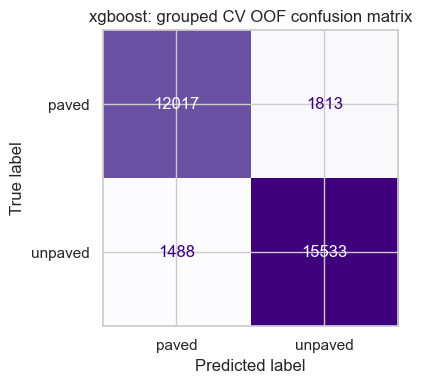

In [10]:
cv = GroupKFold(n_splits=5)
rows = []
all_true, all_pred = [], []

for fold, (tr, te) in enumerate(cv.split(X_train_all, y_train_all, groups=groups), start=1):
    est = make_model(MODEL_NAME)
    fit_model(est, X_train_all.iloc[tr], y_train_all.iloc[tr])
    pred, _ = predict_labels_and_proba(est, X_train_all.iloc[te])
    yte = y_train_all.iloc[te]

    p_, r_, f1_, _ = precision_recall_fscore_support(yte, pred, labels=LABELS, zero_division=0)
    rows.append({
        "fold": fold,
        "accuracy": accuracy_score(yte, pred),
        "macro_f1": float(np.mean(f1_)),
        "mcc": matthews_corrcoef(yte, pred),
        "paved_f1": f1_[0],
        "unpaved_f1": f1_[1],
        "paved_recall": r_[0],
        "unpaved_recall": r_[1],
    })
    all_true.extend(yte.tolist())
    all_pred.extend(pred.tolist())

cv_results = pd.DataFrame(rows)
cv_f1s = cv_results["macro_f1"].tolist()  # stored for fclass Wilcoxon below
display(cv_results.agg(["mean", "std"]).round(3))
print(classification_report(all_true, all_pred, labels=LABELS, digits=3, zero_division=0))

cm = confusion_matrix(all_true, all_pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title(f"{MODEL_NAME}: grouped CV OOF confusion matrix")
plt.tight_layout()
plt.show()

## 5b. fclass-only baseline

Trains the same model using only `fclass` one-hot columns — no satellite features.
Quantifies how much the satellite imagery adds beyond road-class labels alone.
Same 5-fold GroupKFold as the CV sanity check above.

In [11]:
# ---- fclass-only baseline ------------------------------------------------
from scipy.stats import wilcoxon as _wilcoxon

fclass_cols = [c for c in feature_cols if "fclass" in c.lower()]
print(f"fclass columns ({len(fclass_cols)}): {fclass_cols}")

if not fclass_cols:
    print("No fclass columns found in feature_cols — skipping fclass baseline.")
else:
    X_fc = X_train_all[fclass_cols].copy()

    cv_fc = GroupKFold(n_splits=5)
    fc_rows, fc_true, fc_pred_all = [], [], []

    for fold, (tr, te) in enumerate(cv_fc.split(X_fc, y_train_all, groups=groups), start=1):
        est_fc = make_model(MODEL_NAME)
        fit_model(est_fc, X_fc.iloc[tr], y_train_all.iloc[tr])
        pred_fc, _ = predict_labels_and_proba(est_fc, X_fc.iloc[te])
        yte_fc = y_train_all.iloc[te]

        p_, r_, f1_, _ = precision_recall_fscore_support(
            yte_fc, pred_fc, labels=LABELS, zero_division=0
        )
        fc_rows.append({
            "fold": fold,
            "accuracy": accuracy_score(yte_fc, pred_fc),
            "macro_f1": float(np.mean(f1_)),
            "mcc": matthews_corrcoef(yte_fc, pred_fc),
            "paved_f1": f1_[0],
            "unpaved_f1": f1_[1],
        })
        fc_true.extend(yte_fc.tolist())
        fc_pred_all.extend(pred_fc.tolist())

    fc_results = pd.DataFrame(fc_rows)
    fclass_f1s = fc_results["macro_f1"].tolist()

    print("\nfclass-only CV results (mean ± std):")
    display(fc_results.agg(["mean", "std"]).round(3))

    sat_mean = float(np.mean(cv_f1s))
    fc_mean  = float(np.mean(fclass_f1s))
    print(f"\nSatellite model macro-F1 : {sat_mean:.3f}")
    print(f"fclass-only   macro-F1   : {fc_mean:.3f}")
    print(f"Satellite uplift          : {sat_mean - fc_mean:+.3f}")

    stat_fc, p_fc = _wilcoxon(cv_f1s, fclass_f1s, alternative="greater")
    print(f"Wilcoxon p-value (satellite > fclass-only): {p_fc:.4f}")
    if p_fc < 0.05:
        print("→ Satellite features add statistically significant signal over fclass alone.")
    else:
        print("→ Satellite improvement over fclass alone is NOT statistically significant.")


fclass columns (7): ['fclass_residential', 'fclass_service', 'fclass_trunk', 'fclass_primary', 'fclass_secondary', 'fclass_tertiary', 'fclass_unclassified']

fclass-only CV results (mean ± std):


,fold,accuracy,macro_f1,mcc,paved_f1,unpaved_f1
mean,3.000,0.749,0.738,0.493,0.684,0.792
std,1.581,0.004,0.005,0.010,0.009,0.003



Satellite model macro-F1 : 0.892
fclass-only   macro-F1   : 0.738
Satellite uplift          : +0.154
Wilcoxon p-value (satellite > fclass-only): 0.0312
→ Satellite features add statistically significant signal over fclass alone.


## 6. Fit final model and predict all roads

In [12]:
final_model = make_model(MODEL_NAME)
fit_model(final_model, X_train_all, y_train_all)

X_predict = features_all[feature_cols].copy()
pred, proba_df = predict_labels_and_proba(final_model, X_predict)

pred_df = features_all[["osm_id"]].copy()
pred_df["pred_surface"] = pred
pred_df = pd.concat([pred_df, proba_df.reset_index(drop=True)], axis=1)

prob_cols = [c for c in pred_df.columns if c.startswith("prob_")]
pred_df["confidence"] = pred_df[prob_cols].max(axis=1)
pred_df["low_confidence"] = pred_df["confidence"] < LOW_CONFIDENCE_THRESHOLD

# Add fclass and region for summaries.
fclass_mode = (
    s2_all[["osm_id", "fclass"]]
    .dropna()
    .groupby("osm_id")["fclass"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)
pred_df = pred_df.merge(fclass_mode, on="osm_id", how="left")

lookup_path = DATA_DIR / "roads_region_lookup.csv"
if lookup_path.exists():
    region_lookup = pd.read_csv(lookup_path, usecols=["osm_id", "region"])
    region_lookup["osm_id"] = region_lookup["osm_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
    pred_df = pred_df.merge(region_lookup.drop_duplicates("osm_id"), on="osm_id", how="left")
else:
    pred_df["region"] = np.nan

pred_df["is_labelled_train_road"] = pred_df["osm_id"].isin(set(train_df["osm_id"]))

print("Predicted roads:", len(pred_df))
print("Low-confidence roads:", int(pred_df["low_confidence"].sum()))
display(pred_df.head())

Predicted roads: 326546
Low-confidence roads: 21925


,osm_id,pred_surface,prob_paved,prob_unpaved,confidence,low_confidence,fclass,region,is_labelled_train_road
0,1000044406,unpaved,0.038794,0.961206,0.961206,False,residential,Upper West,False
1,1000069142,unpaved,0.005862,0.994138,0.994138,False,residential,Upper West,False
2,1000268792,unpaved,0.473010,0.526990,0.526990,True,service,Eastern,False
3,1000268793,unpaved,0.421661,0.578339,0.578339,True,service,Eastern,False
4,1000268794,unpaved,0.290134,0.709866,0.709866,False,service,Eastern,False


Computing SHAP values on 1000 samples...
SHAP summary — xgboost 


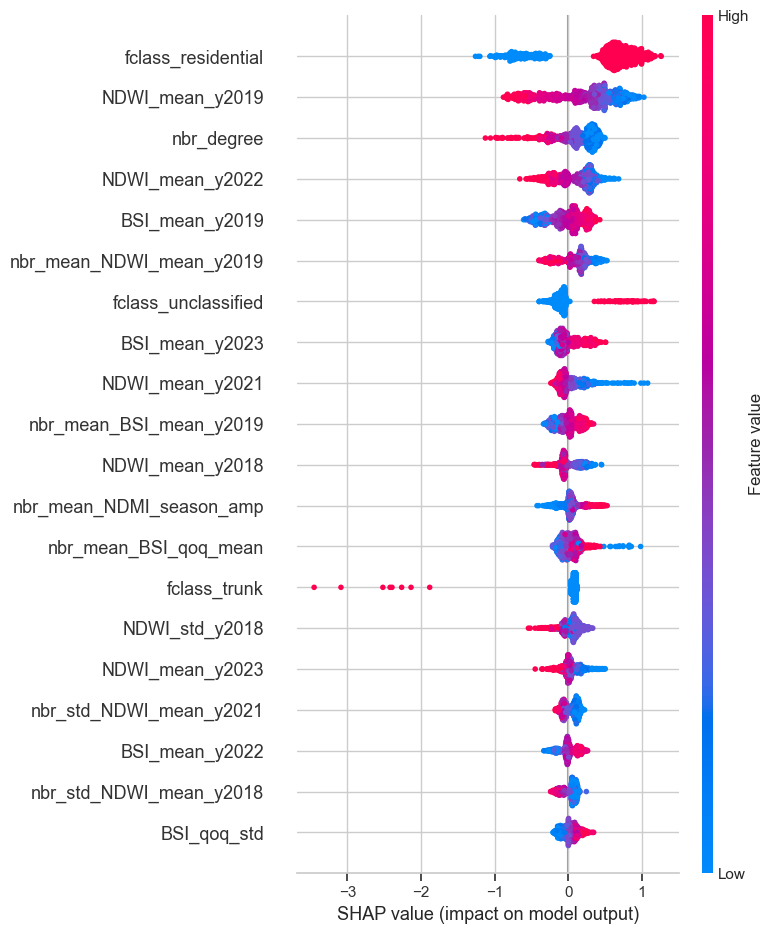

In [13]:
# ---- SHAP interpretability: final model on 1 000-sample subset ----------
if not shap_available:
    print("SHAP not available. Install with: pip install shap")
else:
    n_shap = min(1000, len(features_all))
    rng = np.random.default_rng(42)
    shap_idx = rng.choice(len(features_all), size=n_shap, replace=False)
    X_shap = features_all[feature_cols].iloc[shap_idx].copy()

    print(f"Computing SHAP values on {n_shap} samples...")
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_shap)

    # TreeExplainer may return list [class_0, class_1] for binary classifiers
    if isinstance(shap_values, list):
        shap_vals_plot = shap_values[1]   # unpaved class
        suffix = "(unpaved class)"
    else:
        shap_vals_plot = shap_values
        suffix = ""

    print(f"SHAP summary — {MODEL_NAME} {suffix}")
    shap.summary_plot(
        shap_vals_plot, X_shap,
        feature_names=feature_cols,
        plot_type="dot",
        show=True,
        max_display=20,
    )


## 7. Full-network charts

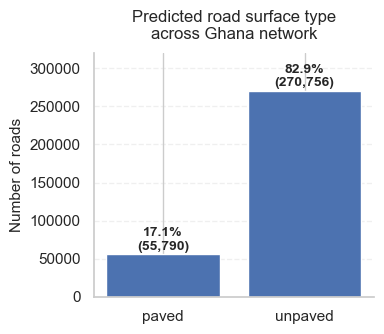

In [14]:
# ── Figure: National predicted surface split ───────────────────────────

national = pred_df['pred_surface'].value_counts().reindex(['paved', 'unpaved'])
national_pct = national / national.sum() * 100

fig, ax = plt.subplots(figsize=(4, 3.5))
bars = ax.bar(
    national.index, national.values,
)
for bar, pct in zip(bars, national_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1500,
        f'{pct:.1f}%\n({int(bar.get_height()):,})',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
ax.set_ylabel('Number of roads', fontsize=11)
ax.set_xlabel('')
ax.set_title('Predicted road surface type\nacross Ghana network', fontsize=12, pad=10)
ax.set_ylim(0, national.max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.show()


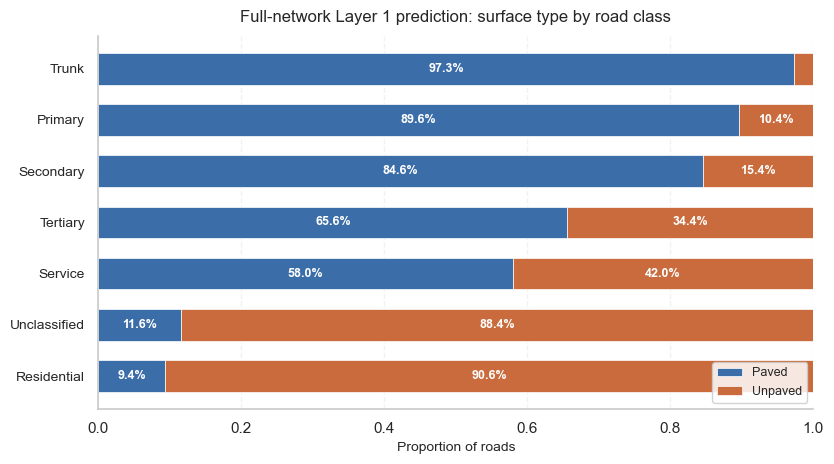

In [23]:
# ── Figure: Predicted surface mix by functional road class ───────────────────
by_class = (
    pred_df.groupby(["fclass", "pred_surface"])
    .size()
    .unstack(fill_value=0)
    .reindex(FOCUS_CLASSES)
)

by_class_pct = by_class.div(by_class.sum(axis=1), axis=0).fillna(0)

# Sort by paved fraction ascending
order = by_class_pct["paved"].sort_values(ascending=True).index
pct_sorted = by_class_pct.loc[order]

fig, ax = plt.subplots(figsize=(8.5, 4.8))

paved_vals = pct_sorted["paved"].values
unpaved_vals = pct_sorted["unpaved"].values
y_pos = range(len(order))

PAVED_COL = "#3B6EA8"
UNPAVED_COL = "#C96B3C"

ax.barh(
    y_pos,
    paved_vals,
    color=PAVED_COL,
    height=0.62,
    label="Paved",
    edgecolor="white",
    linewidth=0.5,
)

ax.barh(
    y_pos,
    unpaved_vals,
    left=paved_vals,
    color=UNPAVED_COL,
    height=0.62,
    label="Unpaved",
    edgecolor="white",
    linewidth=0.5,
)

for i, (pv, uv) in enumerate(zip(paved_vals, unpaved_vals)):
    if pv > 0.06:
        ax.text(
            pv / 2,
            i,
            f"{pv * 100:.1f}%",
            va="center",
            ha="center",
            color="white",
            fontsize=9,
            fontweight="bold",
        )

    if uv > 0.06:
        ax.text(
            pv + uv / 2,
            i,
            f"{uv * 100:.1f}%",
            va="center",
            ha="center",
            color="white",
            fontsize=9,
            fontweight="bold",
        )

ax.set_yticks(y_pos)
ax.set_yticklabels([c.capitalize() for c in order], fontsize=10)
ax.set_xlim(0, 1)

ax.set_xlabel("Proportion of roads", fontsize=10)
ax.set_title(
    "Full-network Layer 1 prediction: surface type by road class",
    fontsize=12,
    pad=10,
)

ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, alpha=0.25, linestyle="--")
ax.set_axisbelow(True)

ax.legend(
    loc="lower right",
    fontsize=9,
    framealpha=0.85,
    edgecolor="#CCCCCC",
)

plt.tight_layout()
plt.show()

/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_22558/2715605572.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


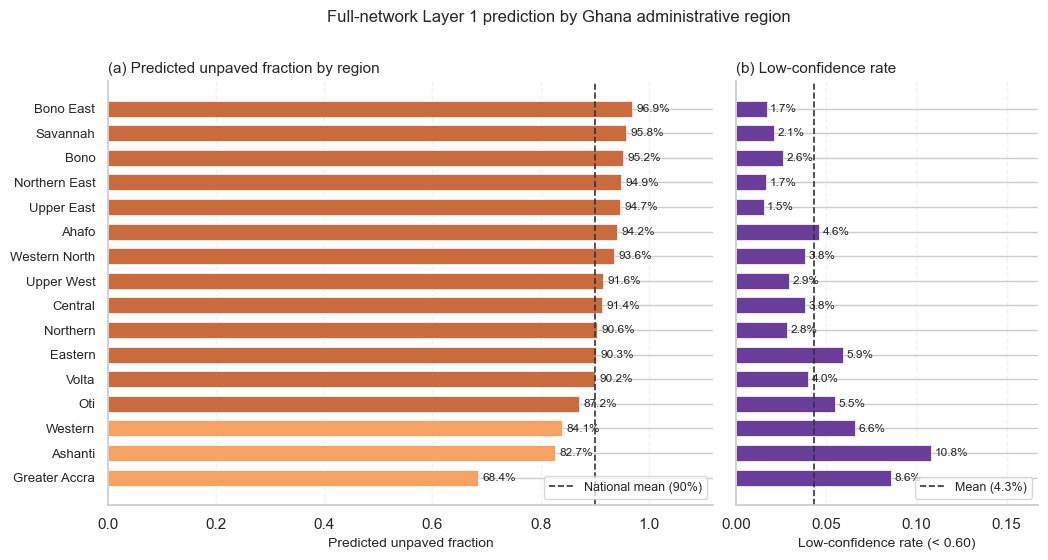

In [16]:
# ── Figure: Regional unpaved fraction + low-confidence rate (replaces Table 16) ──
if 'region' not in pred_df.columns or pred_df['region'].isna().all():
    print('No region data available — ensure roads_region_lookup.csv is present.')
else:
    by_region = (
        pred_df.dropna(subset=['region'])
        .groupby(['region', 'pred_surface'])
        .size()
        .unstack(fill_value=0)
    )
    for lbl in LABELS:
        if lbl not in by_region.columns:
            by_region[lbl] = 0
    by_region['total'] = by_region[LABELS].sum(axis=1)
    by_region['unpaved_frac'] = by_region['unpaved'] / by_region['total']

    low_conf = (
        pred_df.dropna(subset=['region'])
        .groupby('region')['low_confidence']
        .mean()
        .rename('low_conf_rate')
    )
    by_region = by_region.join(low_conf)

    # Sort by unpaved fraction descending
    by_region = by_region.sort_values('unpaved_frac', ascending=True)  # ascending=True → top = most unpaved
    regions   = by_region.index.tolist()
    y_pos     = range(len(regions))

    nat_mean_unpaved = by_region['unpaved_frac'].mean()
    nat_mean_lowconf = by_region['low_conf_rate'].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5),
                              gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.05})

    # ── Panel (a): unpaved fraction ──────────────────────────────────────────
    ax = axes[0]
    colors_a = [UNPAVED_COL if v > 0.85 else ('#f6a262' if v > 0.6 else '#fdd0a2')
                for v in by_region['unpaved_frac'].values]
    ax.barh(y_pos, by_region['unpaved_frac'].values,
            color=colors_a, height=0.65, edgecolor='white', linewidth=0.5)
    ax.axvline(nat_mean_unpaved, color='#333333', linestyle='--', linewidth=1.2,
               label=f'National mean ({nat_mean_unpaved*100:.0f}%)')
    for i, (v, total) in enumerate(zip(by_region['unpaved_frac'].values,
                                       by_region['total'].values)):
        ax.text(v + 0.008, i, f'{v*100:.1f}%', va='center', fontsize=8.5, color='#222222')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(regions, fontsize=9.5)
    ax.set_xlim(0, 1.12)
    ax.set_xlabel('Predicted unpaved fraction', fontsize=10)
    ax.set_title('(a) Predicted unpaved fraction by region', fontsize=11, loc='left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.grid(True, alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, loc='lower right', framealpha=0.75)

    # ── Panel (b): low-confidence rate ──────────────────────────────────────
    ax2 = axes[1]
    ax2.barh(y_pos, by_region['low_conf_rate'].values,
             color='#6a3d9a', height=0.65, edgecolor='white', linewidth=0.5)
    ax2.axvline(nat_mean_lowconf, color='#333333', linestyle='--', linewidth=1.2,
                label=f'Mean ({nat_mean_lowconf*100:.1f}%)')
    for i, v in enumerate(by_region['low_conf_rate'].values):
        ax2.text(v + 0.002, i, f'{v*100:.1f}%', va='center', fontsize=8.5, color='#222222')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([])
    ax2.set_xlim(0, by_region['low_conf_rate'].max() * 1.55)
    ax2.set_xlabel('Low-confidence rate (< 0.60)', fontsize=10)
    ax2.set_title('(b) Low-confidence rate', fontsize=11, loc='left')
    ax2.spines[['top', 'right']].set_visible(False)
    ax2.xaxis.grid(True, alpha=0.25, linestyle='--')
    ax2.set_axisbelow(True)
    ax2.legend(fontsize=9, loc='lower right', framealpha=0.75)

    plt.suptitle('Full-network Layer 1 prediction by Ghana administrative region',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


## 8. Spatial analysis of predicted surface type

Two complementary spatial analyses are run:

1. **Kruskal-Wallis test**: tests whether predicted unpaved probability differs
   significantly across Ghana's 16 administrative regions (non-parametric,
   no distributional assumptions).

2. **Moran's I**: tests for omnidirectional spatial clustering of region-level
   unpaved fractions using KNN weights from region centroids (n=16 regions).
   Reported for completeness; the low n limits power.


Kruskal-Wallis H = 61335.25,  df = 15,  p = 0.00e+00
Regions: 16,  Roads: 324,832
-> Highly significant (p < 0.001): predicted surface type distributions
   differ substantially across administrative regions.

Median predicted unpaved probability by region:


,n,median,mean,std
region,,,,
Savannah,4899,0.992,0.926,0.177
Upper East,7597,0.991,0.926,0.193
Northern,16617,0.988,0.884,0.241
Northern East,1514,0.984,0.919,0.191
Oti,2221,0.964,0.827,0.267
Western North,4579,0.962,0.883,0.192
Bono East,9636,0.958,0.906,0.154
Upper West,8609,0.952,0.861,0.227
Bono,13697,0.948,0.884,0.177


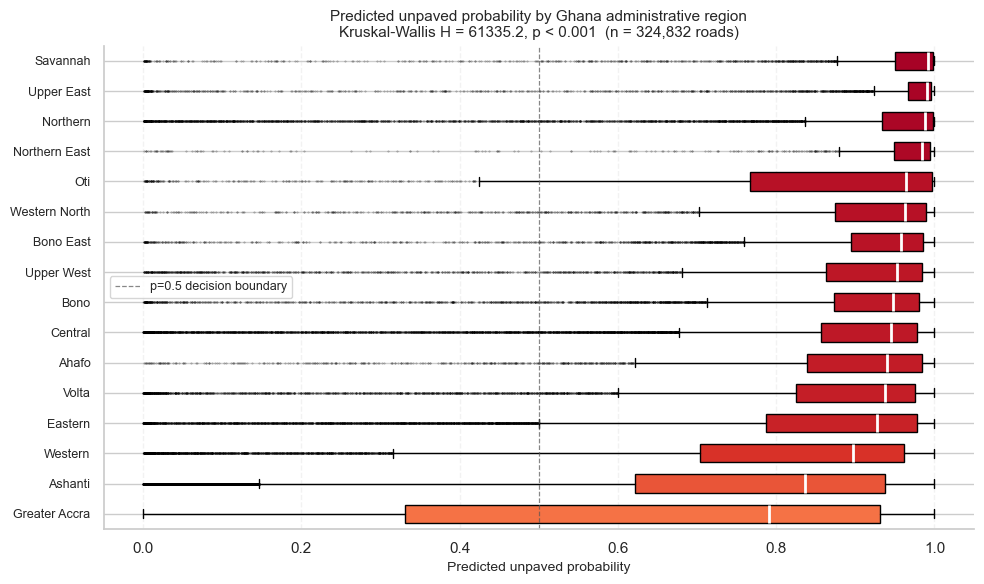

In [20]:
# ── Kruskal-Wallis test: predicted unpaved probability across regions ────────
# Tests H0: the distribution of predicted unpaved probability is identical
# across all 16 Ghana administrative regions.
# Uses the continuous prob_unpaved score (not the binary label) for KW.
# Reference: Kruskal & Wallis (1952), JASA 47(260):583-621.

from scipy.stats import kruskal

if "region" not in pred_df.columns or pred_df["region"].isna().all():
    print("No region data in pred_df. Ensure roads_region_lookup.csv is present.")
else:
    region_groups = [
        grp["prob_unpaved"].dropna().values
        for _, grp in pred_df.dropna(subset=["region"]).groupby("region")
        if len(grp) >= 5
    ]
    region_names = [
        name for name, grp in pred_df.dropna(subset=["region"]).groupby("region")
        if len(grp) >= 5
    ]

    stat_kw, p_kw = kruskal(*region_groups)
    n_regions = len(region_groups)
    n_roads   = pred_df["region"].notna().sum()

    print(f"Kruskal-Wallis H = {stat_kw:.2f},  df = {n_regions - 1},  p = {p_kw:.2e}")
    print(f"Regions: {n_regions},  Roads: {n_roads:,}")

    if p_kw < 0.001:
        print("-> Highly significant (p < 0.001): predicted surface type distributions")
        print("   differ substantially across administrative regions.")
    elif p_kw < 0.05:
        print("-> Significant (p < 0.05): regional differences in predicted surface type.")
    else:
        print("-> Not significant: no evidence of regional variation in predicted surface type.")

    # ── Median unpaved probability by region (summary table) ──────────────────
    kw_summary = (
        pred_df.dropna(subset=["region"])
        .groupby("region")["prob_unpaved"]
        .agg(n="count", median="median", mean="mean", std="std")
        .sort_values("median", ascending=False)
        .round(3)
    )
    print("\nMedian predicted unpaved probability by region:")
    display(kw_summary)

    # ── Box plot ───────────────────────────────────────────────────────────────
    import matplotlib.pyplot as plt

    order = (
        pred_df.dropna(subset=["region"])
        .groupby("region")["prob_unpaved"]
        .median()
        .sort_values(ascending=True)
        .index.tolist()
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    data_by_region = [
        pred_df.loc[pred_df["region"] == r, "prob_unpaved"].dropna().values
        for r in order
    ]
    bp = ax.boxplot(
        data_by_region,
        vert=False,
        patch_artist=True,
        medianprops=dict(color="white", linewidth=2),
        flierprops=dict(marker=".", markersize=1, alpha=0.3),
        widths=0.6,
    )
    colors = plt.cm.RdYlGn_r(
        [pred_df.loc[pred_df["region"] == r, "prob_unpaved"].median() for r in order]
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    ax.set_yticks(range(1, len(order) + 1))
    ax.set_yticklabels(order, fontsize=9)
    ax.set_xlabel("Predicted unpaved probability", fontsize=10)
    ax.set_title(
        f"Predicted unpaved probability by Ghana administrative region\n"
        f"Kruskal-Wallis H = {stat_kw:.1f}, p < 0.001  (n = {n_roads:,} roads)",
        fontsize=11,
    )
    ax.axvline(0.5, color="#555555", linestyle="--", linewidth=0.9, alpha=0.7,
               label="p=0.5 decision boundary")
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.grid(True, alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


Regions: 16


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_22558/4169481865.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,region,unpaved_frac,n_roads
0,Bono East,0.969178,9636.0
1,Savannah,0.958155,4899.0
2,Bono,0.952325,13697.0
3,Northern East,0.949141,1514.0
4,Upper East,0.947084,7597.0
5,Ahafo,0.941913,5113.0
6,Western North,0.935794,4579.0
7,Upper West,0.915786,8609.0
8,Central,0.914173,28266.0
9,Northern,0.905518,16617.0


Using hardcoded Ghana region centroids.
Regions matched to centroids: 16 / 16

Moran's I  : 0.1135
E[I] (H0)  : -0.0667
p-value    : 0.0420  (999 permutations)
→ Significant POSITIVE spatial autocorrelation.
  Unpaved roads cluster geographically — consistent with policy blind-spot hypothesis.


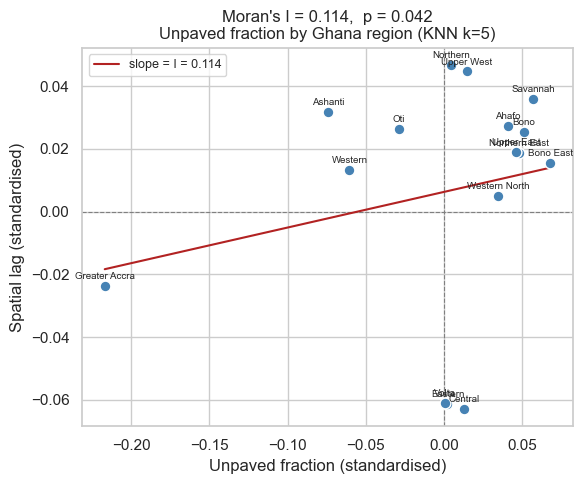

In [18]:
# ---- Moran's I spatial autocorrelation: unpaved fraction by region ------
# Builds spatial weights from region centroids rather than requiring a
# separate polygon shapefile.  Centroid source priority:
#   1. OSM road geometry (available if train_df has geometry in this session)
#   2. Hardcoded Ghana region centroids (fallback — always works)

try:
    import libpysal
    import esda
    morans_available = True
except ImportError:
    morans_available = False
    print("libpysal / esda not installed. Run: pip install libpysal esda")

if not morans_available:
    pass
elif "region" not in pred_df.columns or pred_df["region"].isna().all():
    print("No region data in pred_df. Ensure roads_region_lookup.csv is present.")
else:
    # ── 1. Unpaved fraction per region ────────────────────────────────────
    region_stats = (
        pred_df.dropna(subset=["region"])
        .groupby("region", group_keys=False)
        .apply(lambda g: pd.Series({
            "unpaved_frac": (g["pred_surface"] == "unpaved").mean(),
            "n_roads": len(g),
        }))
        .reset_index()
    )
    print(f"Regions: {len(region_stats)}")
    display(region_stats.sort_values("unpaved_frac", ascending=False)
            .reset_index(drop=True))

    # ── 2. Region centroids ───────────────────────────────────────────────
    # Try to extract centroids from OSM road geometry if present in session
    centroids = None

    if "train_df" in globals() and hasattr(train_df, "geometry"):
        try:
            import geopandas as gpd
            # Attach region via roads_region_lookup
            lookup_path = DATA_DIR / "roads_region_lookup.csv"
            if lookup_path.exists():
                rlookup = pd.read_csv(lookup_path, usecols=["osm_id", "region"])
                rlookup["osm_id"] = rlookup["osm_id"].astype(str).str.strip()
                geo = train_df[["osm_id", "geometry"]].copy()
                geo["osm_id"] = geo["osm_id"].astype(str).str.strip()
                geo = geo.merge(rlookup, on="osm_id", how="left").dropna(subset=["region"])
                geo = gpd.GeoDataFrame(geo, geometry="geometry")
                geo["centroid"] = geo.geometry.centroid
                centroids = (
                    geo.groupby("region")
                    .apply(lambda g: pd.Series({
                        "lon": g["centroid"].x.mean(),
                        "lat": g["centroid"].y.mean(),
                    }))
                    .reset_index()
                )
                print("Centroids derived from OSM road geometry.")
        except Exception as _e:
            print(f"Could not extract OSM centroids ({_e}); using hardcoded fallback.")

    if centroids is None:
        # Hardcoded approximate centroids for Ghana's 16 regions (WGS84)
        _ghana_centroids = {
            "Ahafo":         (-2.55,  7.60),
            "Ashanti":       (-1.60,  6.70),
            "Bono":          (-2.70,  7.75),
            "Bono East":     (-1.60,  7.85),
            "Central":       (-1.20,  5.55),
            "Eastern":       (-0.45,  6.55),
            "Greater Accra": (-0.18,  5.60),
            "North East":    (-0.30, 10.55),
            "Northern":      (-1.05,  9.55),
            "Northern East": (-0.30, 10.55),  # alt spelling of North East
            "Oti":           ( 0.30,  8.00),
            "Savannah":      (-1.60,  9.10),
            "Upper East":    (-0.75, 10.80),
            "Upper West":    (-2.35, 10.55),
            "Volta":         ( 0.50,  6.90),
            "Western":       (-2.55,  5.50),
            "Western North": (-2.85,  6.60),
        }
        centroids = pd.DataFrame([
            {"region": r, "lon": lon, "lat": lat}
            for r, (lon, lat) in _ghana_centroids.items()
        ])
        print("Using hardcoded Ghana region centroids.")

    # ── 3. Merge centroids with region stats ──────────────────────────────
    merged = region_stats.merge(centroids, on="region", how="inner")
    print(f"Regions matched to centroids: {len(merged)} / {len(region_stats)}")

    unmatched = set(region_stats["region"]) - set(merged["region"])
    if unmatched:
        print(f"Unmatched regions (add to hardcoded dict if needed): {unmatched}")

    if len(merged) < 3:
        print("Too few regions for Moran's I.")
    else:
        # ── 4. KNN spatial weights from centroids ─────────────────────────
        coords = merged[["lon", "lat"]].values
        k = min(5, len(merged) - 1)
        w = libpysal.weights.KNN.from_array(coords, k=k)
        w.transform = "r"

        # ── 5. Moran's I ──────────────────────────────────────────────────
        moran = esda.Moran(merged["unpaved_frac"].values, w, permutations=999)

        print(f"\nMoran's I  : {moran.I:.4f}")
        print(f"E[I] (H0)  : {moran.EI:.4f}")
        print(f"p-value    : {moran.p_sim:.4f}  (999 permutations)")

        if moran.p_sim < 0.05 and moran.I > moran.EI:
            print("→ Significant POSITIVE spatial autocorrelation.")
            print("  Unpaved roads cluster geographically — consistent with policy blind-spot hypothesis.")
        elif moran.p_sim < 0.05:
            print("→ Significant spatial autocorrelation (negative / dispersed).")
        else:
            print("→ No significant spatial autocorrelation at p < 0.05.")

        # ── 6. Moran scatter plot ─────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(6, 5))
        lag = libpysal.weights.lag_spatial(w, merged["unpaved_frac"].values)
        x_std = (merged["unpaved_frac"].values - merged["unpaved_frac"].mean())
        y_std = lag - merged["unpaved_frac"].mean()
        ax.scatter(x_std, y_std, color="steelblue", edgecolors="white", s=60, zorder=3)
        for _, row in merged.iterrows():
            xi = row["unpaved_frac"] - merged["unpaved_frac"].mean()
            yi = (lag[merged.index.get_loc(merged[merged["region"]==row["region"]].index[0])]
                  - merged["unpaved_frac"].mean())
            ax.annotate(row["region"], (xi, yi), fontsize=7, ha="center",
                        xytext=(0, 5), textcoords="offset points")
        ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
        ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
        m_fit = np.polyfit(x_std, y_std, 1)
        xr = np.linspace(x_std.min(), x_std.max(), 100)
        ax.plot(xr, np.polyval(m_fit, xr), color="firebrick", linewidth=1.5,
                label=f"slope = I = {moran.I:.3f}")
        ax.set_xlabel("Unpaved fraction (standardised)")
        ax.set_ylabel("Spatial lag (standardised)")
        ax.set_title(f"Moran\'s I = {moran.I:.3f},  p = {moran.p_sim:.3f}\n"
                     f"Unpaved fraction by Ghana region (KNN k={k})")
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()


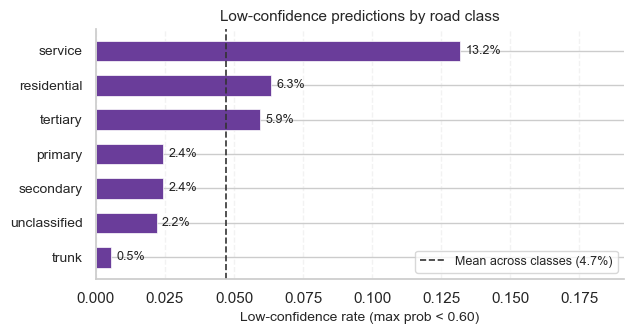

In [19]:
# ── Figure: Low-confidence rate by road class ───────────────────────────
low_by_class = (
    pred_df.groupby('fclass')['low_confidence']
    .agg(['sum', 'count'])
    .assign(rate=lambda d: d['sum'] / d['count'])
    .reindex(FOCUS_CLASSES)
    .dropna()
)
# Sort ascending so highest bar is at top
low_by_class = low_by_class.sort_values('rate', ascending=True)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.barh(
    low_by_class.index,
    low_by_class['rate'].values,
    color='#6a3d9a', height=0.6, edgecolor='white', linewidth=0.5
)
nat_lc = low_by_class['rate'].mean()
ax.axvline(nat_lc, color='#333333', linestyle='--', linewidth=1.2,
           label=f'Mean across classes ({nat_lc*100:.1f}%)')
for i, (cls, row) in enumerate(low_by_class.iterrows()):
    ax.text(row['rate'] + 0.002, i, f"{row['rate']*100:.1f}%",
            va='center', fontsize=9, color='#222222')
ax.set_xlabel('Low-confidence rate (max prob < 0.60)', fontsize=10)
ax.set_xlim(0, low_by_class['rate'].max() * 1.45)
ax.set_title('Low-confidence predictions by road class', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, alpha=0.25, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=9, framealpha=0.75)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()


## Reporting note

The key dissertation outputs from this notebook are:

- predicted paved/unpaved share across all Ghana roads with Sentinel-2 coverage;
- predicted surface mix by road class and region;
- confidence distribution and low-confidence roads;
- whether unlabelled roads have a different prediction/confidence profile from labelled training roads.

No CSV is exported by this notebook. If exports are needed later, add them deliberately in a final cell.

In [24]:
from pathlib import Path

# ---------------------------------------------------------------------
# Export Layer 1 full-network predictions for Network Inspector app
# ---------------------------------------------------------------------

APP_EXPORT_PATH = Path("../data/layer1_full_network_predictions.parquet")

required_cols = [
    "osm_id",
    "fclass",
    "region",
    "pred_surface",
    "prob_paved",
    "prob_unpaved",
    "confidence",
    "low_confidence",
    "is_labelled_train_road",
]

optional_cols = ["name"]

export_cols = required_cols + [c for c in optional_cols if c in pred_df.columns]
missing = [c for c in required_cols if c not in pred_df.columns]

if missing:
    raise ValueError(f"Missing required columns in pred_df: {missing}")

app_pred_export = pred_df[export_cols].copy()

# Keep IDs stable for frontend/backend joins.
app_pred_export["osm_id"] = app_pred_export["osm_id"].astype(str)

# Normalise booleans for clean parquet round-tripping.
app_pred_export["low_confidence"] = app_pred_export["low_confidence"].astype(bool)
app_pred_export["is_labelled_train_road"] = app_pred_export["is_labelled_train_road"].astype(bool)

# Confidence/probabilities as numeric floats.
for col in ["prob_paved", "prob_unpaved", "confidence"]:
    app_pred_export[col] = pd.to_numeric(app_pred_export[col], errors="coerce")

APP_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
app_pred_export.to_parquet(APP_EXPORT_PATH, index=False)

print(f"Exported {len(app_pred_export):,} Layer 1 predictions to:")
print(APP_EXPORT_PATH.resolve())

display(app_pred_export.head())

Exported 326,546 Layer 1 predictions to:
/Users/miranda/Documents/GitHub/Sentinel-FYP/data/layer1_full_network_predictions.parquet


,osm_id,fclass,region,pred_surface,prob_paved,prob_unpaved,confidence,low_confidence,is_labelled_train_road
0,1000044406,residential,Upper West,unpaved,0.038794,0.961206,0.961206,False,False
1,1000069142,residential,Upper West,unpaved,0.005862,0.994138,0.994138,False,False
2,1000268792,service,Eastern,unpaved,0.473010,0.526990,0.526990,True,False
3,1000268793,service,Eastern,unpaved,0.421661,0.578339,0.578339,True,False
4,1000268794,service,Eastern,unpaved,0.290134,0.709866,0.709866,False,False
